Survived - 생존유무, target 값. (0 = 사망, 1 = 생존)

Name - 탑승객 성명

Pclass - 티켓 클래스. (1 = 1st, 2 = 2nd, 3 = 3rd)

Sex - 성별

Age - 나이(세)

SibSp - 함께 탑승한 형제자매, 배우자 수 총합

Parch - 함께 탑승한 부모, 자녀 수 총합

Embarked - 탑승 항구

Fare - 탑승 요금

Ticket - 티켓 넘버

Cabin - 객실 넘버

In [1]:
import pandas as pd

df = pd.read_csv('./train.csv')

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df2 = df.copy()

# 결측값 처리

In [5]:
df2['Age'] = df2['Age'].fillna(df2['Age'].mean())

In [6]:
len(df2['Age'])

891

In [7]:
df2['Embarked'] = df2['Embarked'].fillna(df2['Embarked'].mode()[0])

In [8]:
len(df['Embarked'])

891

In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
df2 = df2.drop(labels = ['PassengerId', 'Name', 'Ticket', 'Cabin'], axis = 1)

In [11]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [12]:
df2 = pd.get_dummies(df2, columns=['Sex', 'Embarked'], drop_first=True)

In [13]:
df2.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [14]:
df2.corr(numeric_only=True)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
Survived,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307,-0.543351,0.003650,-0.149683
Pclass,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500,0.131900,0.221009,0.074053
Age,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566,0.084153,-0.013855,-0.019336
SibSp,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651,-0.114631,-0.026354,0.068734
Parch,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225,-0.245489,-0.081228,0.060814
Fare,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000,-0.182333,-0.117216,-0.162184
Sex_male,-0.543351,0.131900,0.084153,-0.114631,-0.245489,-0.182333,1.000000,-0.074115,0.119224
Embarked_Q,0.003650,0.221009,-0.013855,-0.026354,-0.081228,-0.117216,-0.074115,1.000000,-0.499421
Embarked_S,-0.149683,0.074053,-0.019336,0.068734,0.060814,-0.162184,0.119224,-0.499421,1.000000


# minmaxsklearn를 사용

In [15]:
from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['Age', 'Fare']

scaler = MinMaxScaler()

df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale])

In [16]:
df2.head(10)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,0.271174,1,0,0.014151,True,False,True
1,1,1,0.472229,1,0,0.139136,False,False,False
2,1,3,0.321438,0,0,0.015469,False,False,True
3,1,1,0.434531,1,0,0.103644,False,False,True
4,0,3,0.434531,0,0,0.015713,True,False,True
5,0,3,0.367921,0,0,0.016510,True,True,False
6,0,1,0.673285,0,0,0.101229,True,False,True
7,0,3,0.019854,3,1,0.041136,True,False,True
8,1,3,0.334004,0,2,0.021731,False,False,True
9,1,2,0.170646,1,0,0.058694,False,False,False


In [17]:
df2.iloc[:, 1:]

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,0.271174,1,0,0.014151,True,False,True
1,1,0.472229,1,0,0.139136,False,False,False
2,3,0.321438,0,0,0.015469,False,False,True
3,1,0.434531,1,0,0.103644,False,False,True
4,3,0.434531,0,0,0.015713,True,False,True
...,...,...,...,...,...,...,...,...
886,2,0.334004,0,0,0.025374,True,False,True
887,1,0.233476,0,0,0.058556,False,False,True
888,3,0.367921,1,2,0.045771,False,False,True
889,1,0.321438,0,0,0.058556,True,False,False


In [18]:
df2.iloc[:, :1]

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df2.iloc[:, 1:], 
    df2.iloc[:, :1], 
    test_size = 0.2,
    random_state = 42
)

In [20]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 8), (179, 8), (712, 1), (179, 1))

In [21]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # 이진 분류용 출력층

In [36]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [37]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

In [38]:
y_train_array = y_train.to_numpy().ravel().astype(np.float32)
y_test_array = y_test.to_numpy().ravel().astype(np.float32)

In [39]:
history = model.fit(
    X_train, 
    y_train_array, 
    epochs=100, 
    batch_size=64,
    validation_data = (X_test, y_test_array),
)

Epoch 1/100
12/12 [==============================] - 1s 11ms/step - loss: 0.6703 - accuracy: 0.6110 - val_loss: 0.6770 - val_accuracy: 0.5810
Epoch 2/100
12/12 [==============================] - 0s 3ms/step - loss: 0.6526 - accuracy: 0.6180 - val_loss: 0.6677 - val_accuracy: 0.5866
Epoch 3/100
12/12 [==============================] - 0s 5ms/step - loss: 0.6415 - accuracy: 0.6222 - val_loss: 0.6566 - val_accuracy: 0.5922
Epoch 4/100
12/12 [==============================] - 0s 5ms/step - loss: 0.6318 - accuracy: 0.6222 - val_loss: 0.6465 - val_accuracy: 0.5922
Epoch 5/100
12/12 [==============================] - 0s 4ms/step - loss: 0.6234 - accuracy: 0.6236 - val_loss: 0.6376 - val_accuracy: 0.5922
Epoch 6/100
12/12 [==============================] - 0s 4ms/step - loss: 0.6156 - accuracy: 0.6306 - val_loss: 0.6291 - val_accuracy: 0.5978
Epoch 7/100
12/12 [==============================] - 0s 4ms/step - loss: 0.6077 - accuracy: 0.6292 - val_loss: 0.6204 - val_accuracy: 0.5866
Epoch 8/100


In [40]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [41]:
results = model.evaluate(X_test, y_test, verbose=1)

print("loss =", results[0])
print("accuracy =", results[1])

6/6 [==============================] - 0s 3ms/step - loss: 0.4388 - accuracy: 0.7877
loss = 0.4387698471546173
accuracy = 0.7877094745635986


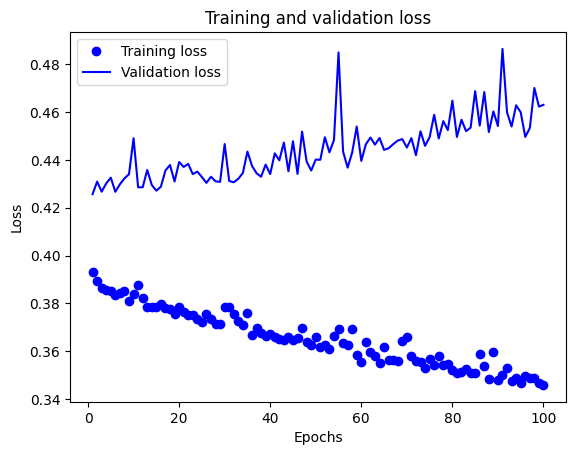

In [117]:
import matplotlib.pyplot as plt

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, loss, 'bo', label = 'Training loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()